## Library Imports

In [1]:
# ============================================================
# Import required libraries
#
# Purpose:
# Load the Python packages needed for:
# - Data manipulation
# - Numerical operations
# - Visualization
# - Machine learning based anomaly detection
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

## Read data

In [2]:
# ============================================================
# Read source CSV files
#
# Purpose:
# Load AWS CUR billing data and Kubernetes metrics data.
# These two datasets will be joined later at daily level.
# ============================================================

aws_cur_path = "../synnepha_exercise_90d/synnepha_exercise_aws_cur_sample_90d.csv"
k8s_metrics_path = "../synnepha_exercise_90d/synnepha_exercise_k8s_metrics_90d.csv"

aws_cur_df = pd.read_csv(aws_cur_path)
k8s_metrics_df = pd.read_csv(k8s_metrics_path)

print("AWS CUR shape:", aws_cur_df.shape)
print("K8s metrics shape:", k8s_metrics_df.shape)

display(aws_cur_df.head())
display(k8s_metrics_df.head())

AWS CUR shape: (8100, 8)
K8s metrics shape: (15120, 8)


,billing_period,date,account_id,service,usage_type,region,cost_usd,usage_quantity
0,2026-01,2026-01-31,acct_001,AmazonEC2,BoxUsage:m5.xlarge,us-east-1,927.48,"4,780.38"
1,2026-01,2026-01-31,acct_001,AmazonEC2,BoxUsage:m5.xlarge,eu-west-1,948.28,"4,985.43"
2,2026-01,2026-01-31,acct_001,AmazonS3,TimedStorage-ByteHrs,us-east-1,249.25,"10,695,835.07"
3,2026-01,2026-01-31,acct_001,AmazonS3,TimedStorage-ByteHrs,eu-west-1,287.45,"12,458,092.77"
4,2026-01,2026-01-31,acct_001,AmazonRDS,InstanceUsage:db.r5.large,us-east-1,592.14,"2,446.20"


,timestamp,pod_name,namespace,node,cpu_usage_cores,memory_usage_mb,cpu_request_cores,memory_request_mb
0,2026-01-31T00:00:00Z,api-gateway-7f8d9,production,node-01,0.13,199.10,0.50,512
1,2026-01-31T00:00:00Z,batch-processor-1d5f3,production,node-01,0.38,976.10,1.00,2048
2,2026-01-31T00:00:00Z,cache-layer-5f1d9,production,node-01,0.24,484.10,0.50,1024
3,2026-01-31T00:00:00Z,data-pipeline-4a2c1,production,node-02,0.78,"1,912.10",2.00,4096
4,2026-01-31T00:00:00Z,legacy-etl-2e7b4,production,node-03,0.05,86.20,2.00,4096


## Basic schema validation

In [3]:
# ============================================================
# Basic schema validation
#
# Purpose:
# Check whether the expected columns are available.
# This is important before building features or running models.
# ============================================================

print("AWS CUR columns:")
print(aws_cur_df.columns.tolist())

print("\nK8s metrics columns:")
print(k8s_metrics_df.columns.tolist())

print("\nAWS CUR data types:")
display(aws_cur_df.dtypes)

print("\nK8s metrics data types:")
display(k8s_metrics_df.dtypes)

AWS CUR columns:
['billing_period', 'date', 'account_id', 'service', 'usage_type', 'region', 'cost_usd', 'usage_quantity']

K8s metrics columns:
['timestamp', 'pod_name', 'namespace', 'node', 'cpu_usage_cores', 'memory_usage_mb', 'cpu_request_cores', 'memory_request_mb']

AWS CUR data types:


billing_period     object
date               object
account_id         object
service            object
usage_type         object
region             object
cost_usd          float64
usage_quantity    float64
dtype: object


K8s metrics data types:


timestamp             object
pod_name              object
namespace             object
node                  object
cpu_usage_cores      float64
memory_usage_mb      float64
cpu_request_cores    float64
memory_request_mb      int64
dtype: object

## Parse date and timestamp columns

In [4]:
# ============================================================
# Parse date and timestamp columns
#
# Purpose:
# Convert raw string dates into datetime format.
#
# Important:
# Kubernetes timestamps may contain UTC timezone information.
# AWS billing dates are timezone-naive daily dates.
# To avoid merge errors, both date columns are normalized to
# timezone-naive daily timestamps.
# ============================================================

aws_cur_df["date"] = pd.to_datetime(
    aws_cur_df["date"]
)

k8s_metrics_df["timestamp"] = (
    pd.to_datetime(
        k8s_metrics_df["timestamp"],
        utc=True
    )
    .dt.tz_localize(None)
)

k8s_metrics_df["date"] = (
    k8s_metrics_df["timestamp"]
    .dt.floor("D")
)

print("AWS date range:", aws_cur_df["date"].min(), "to", aws_cur_df["date"].max())
print("K8s date range:", k8s_metrics_df["date"].min(), "to", k8s_metrics_df["date"].max())

print("\nDate column types:")
print("AWS date:", aws_cur_df["date"].dtype)
print("K8s date:", k8s_metrics_df["date"].dtype)

AWS date range: 2026-01-31 00:00:00 to 2026-04-30 00:00:00
K8s date range: 2026-01-31 00:00:00 to 2026-04-30 00:00:00

Date column types:
AWS date: datetime64[ns]
K8s date: datetime64[ns]


## Data quality checks

In [5]:
# ============================================================
# Data quality checks
#
# Purpose:
# Identify basic data quality issues before modelling.
#
# Checks:
# - Missing values
# - Duplicate rows
# - Negative cost or usage
# - Negative Kubernetes resource metrics
# ============================================================

print("AWS CUR missing values:")
display(aws_cur_df.isna().sum())

print("\nK8s metrics missing values:")
display(k8s_metrics_df.isna().sum())

print("\nAWS duplicate rows:", aws_cur_df.duplicated().sum())
print("K8s duplicate rows:", k8s_metrics_df.duplicated().sum())

print("\nNegative AWS cost rows:")
display(aws_cur_df[aws_cur_df["cost_usd"] < 0])

print("\nNegative AWS usage rows:")
display(aws_cur_df[aws_cur_df["usage_quantity"] < 0])

print("\nNegative Kubernetes metric rows:")
display(
    k8s_metrics_df[
        (k8s_metrics_df["cpu_usage_cores"] < 0) |
        (k8s_metrics_df["memory_usage_mb"] < 0) |
        (k8s_metrics_df["cpu_request_cores"] < 0) |
        (k8s_metrics_df["memory_request_mb"] < 0)
    ]
)

AWS CUR missing values:


billing_period    0
date              0
account_id        0
service           0
usage_type        0
region            0
cost_usd          0
usage_quantity    0
dtype: int64


K8s metrics missing values:


timestamp            0
pod_name             0
namespace            0
node                 0
cpu_usage_cores      0
memory_usage_mb      0
cpu_request_cores    0
memory_request_mb    0
date                 0
dtype: int64


AWS duplicate rows: 0
K8s duplicate rows: 0

Negative AWS cost rows:


,billing_period,date,account_id,service,usage_type,region,cost_usd,usage_quantity



Negative AWS usage rows:


,billing_period,date,account_id,service,usage_type,region,cost_usd,usage_quantity



Negative Kubernetes metric rows:


,timestamp,pod_name,namespace,node,cpu_usage_cores,memory_usage_mb,cpu_request_cores,memory_request_mb,date


## Daily AWS feature engineering

In [6]:
# ============================================================
# Aggregate AWS billing data at daily level
#
# Purpose:
# Create a daily cost time series and daily numerical features
# for the machine learning anomaly detection model.
#
# Features:
# - Total daily cost
# - Average and maximum cost record
# - Total and average usage quantity
# - Number of active accounts, services, regions, and usage types
# ============================================================

daily_aws_df = (
    aws_cur_df
    .groupby("date", as_index=False)
    .agg(
        total_cost_usd=("cost_usd", "sum"),
        mean_cost_usd=("cost_usd", "mean"),
        max_cost_usd=("cost_usd", "max"),
        total_usage_quantity=("usage_quantity", "sum"),
        mean_usage_quantity=("usage_quantity", "mean"),
        unique_accounts=("account_id", "nunique"),
        unique_services=("service", "nunique"),
        unique_regions=("region", "nunique"),
        unique_usage_types=("usage_type", "nunique")
    )
    .sort_values("date")
)

display(daily_aws_df.head())
display(daily_aws_df.tail())

,date,total_cost_usd,mean_cost_usd,max_cost_usd,total_usage_quantity,mean_usage_quantity,unique_accounts,unique_services,unique_regions,unique_usage_types
0,2026-01-31,"16,862.60",187.36,"1,025.91","133,458,592.40","1,482,873.25",8,6,4,6
1,2026-02-01,"17,107.44",190.08,"1,002.68","133,314,383.86","1,481,270.93",8,6,4,6
2,2026-02-02,"24,095.45",267.73,"1,612.40","211,286,400.58","2,347,626.67",8,6,4,6
3,2026-02-03,"23,620.45",262.45,"1,777.13","201,351,235.12","2,237,235.95",8,6,4,6
4,2026-02-04,"23,736.00",263.73,"1,638.11","209,291,301.51","2,325,458.91",8,6,4,6


,date,total_cost_usd,mean_cost_usd,max_cost_usd,total_usage_quantity,mean_usage_quantity,unique_accounts,unique_services,unique_regions,unique_usage_types
85,2026-04-26,"17,512.82",194.59,"1,141.98","132,209,617.13","1,468,995.75",8,6,4,6
86,2026-04-27,"23,640.68",262.67,"1,655.50","201,351,198.82","2,237,235.54",8,6,4,6
87,2026-04-28,"26,272.61",291.92,"1,669.97","242,693,748.28","2,696,597.20",8,6,4,6
88,2026-04-29,"27,743.61",308.26,"2,124.27","235,347,154.37","2,614,968.38",8,6,4,6
89,2026-04-30,"27,440.17",304.89,"1,777.20","236,192,537.30","2,624,361.53",8,6,4,6


## Cost trend features

In [7]:
# ============================================================
# Create cost trend features
#
# Purpose:
# Add time-series based features that help the model understand
# whether a day is unusual compared to recent history.
#
# Features:
# - Absolute day-over-day cost change
# - Percentage day-over-day cost change
# - 7-day rolling mean
# - 7-day rolling standard deviation
# - 7-day rolling z-score
# ============================================================

daily_aws_df["cost_diff_abs"] = (
    daily_aws_df["total_cost_usd"]
    .diff()
    .fillna(0)
)

daily_aws_df["cost_diff_pct"] = (
    daily_aws_df["total_cost_usd"]
    .pct_change()
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

daily_aws_df["rolling_mean_7d"] = (
    daily_aws_df["total_cost_usd"]
    .rolling(window=7, min_periods=3)
    .mean()
)

daily_aws_df["rolling_std_7d"] = (
    daily_aws_df["total_cost_usd"]
    .rolling(window=7, min_periods=3)
    .std()
)

daily_aws_df["cost_z_score_7d"] = (
    daily_aws_df["total_cost_usd"] - daily_aws_df["rolling_mean_7d"]
) / daily_aws_df["rolling_std_7d"]

daily_aws_df["cost_z_score_7d"] = (
    daily_aws_df["cost_z_score_7d"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

display(
    daily_aws_df[
        [
            "date",
            "total_cost_usd",
            "cost_diff_abs",
            "cost_diff_pct",
            "cost_z_score_7d"
        ]
    ].head(10)
)

,date,total_cost_usd,cost_diff_abs,cost_diff_pct,cost_z_score_7d
0,2026-01-31,"16,862.60",0.00,0.00,0.00
1,2026-02-01,"17,107.44",244.84,0.01,0.00
2,2026-02-02,"24,095.45","6,988.01",0.41,1.15
3,2026-02-03,"23,620.45",-475.00,-0.02,0.80
4,2026-02-04,"23,736.00",115.55,0.00,0.71
5,2026-02-05,"23,705.73",-30.27,-0.00,0.62
6,2026-02-06,"24,314.63",608.90,0.03,0.71
7,2026-02-07,"17,201.58","-7,113.05",-0.29,-1.45
8,2026-02-08,"16,734.99",-466.59,-0.03,-1.53
9,2026-02-09,"23,290.79","6,555.80",0.39,0.45


## Kubernetes utilization features

In [8]:
# ============================================================
# Create Kubernetes utilization features
#
# Purpose:
# Convert raw CPU and memory metrics into utilization ratios.
#
# Why:
# Absolute CPU or memory usage alone can be misleading.
# Utilization ratio compares actual usage against requested
# resources and helps identify pressure or overuse.
# ============================================================

k8s_metrics_df["cpu_utilization_ratio"] = (
    k8s_metrics_df["cpu_usage_cores"] /
    k8s_metrics_df["cpu_request_cores"]
)

k8s_metrics_df["memory_utilization_ratio"] = (
    k8s_metrics_df["memory_usage_mb"] /
    k8s_metrics_df["memory_request_mb"]
)

k8s_metrics_df = k8s_metrics_df.replace(
    [np.inf, -np.inf],
    np.nan
)

display(
    k8s_metrics_df[
        [
            "timestamp",
            "date",
            "pod_name",
            "cpu_usage_cores",
            "cpu_request_cores",
            "cpu_utilization_ratio",
            "memory_usage_mb",
            "memory_request_mb",
            "memory_utilization_ratio"
        ]
    ].head()
)

,timestamp,date,pod_name,cpu_usage_cores,cpu_request_cores,cpu_utilization_ratio,memory_usage_mb,memory_request_mb,memory_utilization_ratio
0,2026-01-31,2026-01-31,api-gateway-7f8d9,0.13,0.50,0.27,199.10,512,0.39
1,2026-01-31,2026-01-31,batch-processor-1d5f3,0.38,1.00,0.38,976.10,2048,0.48
2,2026-01-31,2026-01-31,cache-layer-5f1d9,0.24,0.50,0.47,484.10,1024,0.47
3,2026-01-31,2026-01-31,data-pipeline-4a2c1,0.78,2.00,0.39,"1,912.10",4096,0.47
4,2026-01-31,2026-01-31,legacy-etl-2e7b4,0.05,2.00,0.02,86.20,4096,0.02


## Daily Kubernetes aggregation

In [9]:
# ============================================================
# Aggregate Kubernetes metrics at daily level
#
# Purpose:
# Create daily infrastructure workload features that can be
# combined with daily AWS cost features.
#
# Features:
# - Average and maximum CPU usage
# - Average and maximum memory usage
# - Average and maximum utilization ratios
# - Number of active pods and nodes
# ============================================================

daily_k8s_df = (
    k8s_metrics_df
    .groupby("date", as_index=False)
    .agg(
        avg_cpu_usage_cores=("cpu_usage_cores", "mean"),
        max_cpu_usage_cores=("cpu_usage_cores", "max"),
        avg_memory_usage_mb=("memory_usage_mb", "mean"),
        max_memory_usage_mb=("memory_usage_mb", "max"),
        avg_cpu_utilization_ratio=("cpu_utilization_ratio", "mean"),
        max_cpu_utilization_ratio=("cpu_utilization_ratio", "max"),
        avg_memory_utilization_ratio=("memory_utilization_ratio", "mean"),
        max_memory_utilization_ratio=("memory_utilization_ratio", "max"),
        active_pods=("pod_name", "nunique"),
        active_nodes=("node", "nunique")
    )
    .sort_values("date")
)

display(daily_k8s_df.head())
display(daily_k8s_df.tail())

,date,avg_cpu_usage_cores,max_cpu_usage_cores,avg_memory_usage_mb,max_memory_usage_mb,avg_cpu_utilization_ratio,max_cpu_utilization_ratio,avg_memory_utilization_ratio,max_memory_utilization_ratio,active_pods,active_nodes
0,2026-01-31,0.51,2.93,"1,063.38","4,279.80",0.36,0.73,0.41,0.66,7,3
1,2026-02-01,0.47,2.39,"1,062.49","4,744.00",0.33,0.68,0.41,0.73,7,3
2,2026-02-02,0.69,3.72,"1,514.90","7,818.40",0.49,1.15,0.57,1.25,7,3
3,2026-02-03,0.72,4.52,"1,507.49","7,465.20",0.49,1.13,0.57,1.14,7,3
4,2026-02-04,0.68,3.66,"1,503.40","7,173.20",0.48,1.10,0.57,1.14,7,3


,date,avg_cpu_usage_cores,max_cpu_usage_cores,avg_memory_usage_mb,max_memory_usage_mb,avg_cpu_utilization_ratio,max_cpu_utilization_ratio,avg_memory_utilization_ratio,max_memory_utilization_ratio,active_pods,active_nodes
85,2026-04-26,0.51,2.25,"1,160.00","4,123.70",0.37,0.72,0.44,0.77,7,3
86,2026-04-27,0.74,3.81,"1,654.02","7,232.10",0.53,1.07,0.62,1.34,7,3
87,2026-04-28,0.72,4.01,"1,667.35","7,665.80",0.53,1.01,0.62,1.42,7,3
88,2026-04-29,0.73,4.14,"1,674.21","7,549.10",0.53,1.10,0.63,1.39,7,3
89,2026-04-30,0.72,3.97,"1,705.08","7,430.70",0.52,1.25,0.64,1.41,7,3


## Merge AWS and Kubernetes features

In [10]:
# ============================================================
# Merge daily AWS and Kubernetes features
#
# Purpose:
# Build the final modelling dataset.
#
# Join key:
# - date
#
# Rationale:
# Cost is available at daily level, so Kubernetes metrics are
# also aggregated to daily level before joining.
# ============================================================

daily_ml_df = daily_aws_df.merge(
    daily_k8s_df,
    on="date",
    how="left"
)

daily_ml_df = daily_ml_df.fillna(0)

print("Final ML dataset shape:", daily_ml_df.shape)

display(daily_ml_df.head())

Final ML dataset shape: (90, 25)


,date,total_cost_usd,mean_cost_usd,max_cost_usd,total_usage_quantity,mean_usage_quantity,unique_accounts,unique_services,unique_regions,unique_usage_types,cost_diff_abs,cost_diff_pct,rolling_mean_7d,rolling_std_7d,cost_z_score_7d,avg_cpu_usage_cores,max_cpu_usage_cores,avg_memory_usage_mb,max_memory_usage_mb,avg_cpu_utilization_ratio,max_cpu_utilization_ratio,avg_memory_utilization_ratio,max_memory_utilization_ratio,active_pods,active_nodes
0,2026-01-31,"16,862.60",187.36,"1,025.91","133,458,592.40","1,482,873.25",8,6,4,6,0.00,0.00,0.00,0.00,0.00,0.51,2.93,"1,063.38","4,279.80",0.36,0.73,0.41,0.66,7,3
1,2026-02-01,"17,107.44",190.08,"1,002.68","133,314,383.86","1,481,270.93",8,6,4,6,244.84,0.01,0.00,0.00,0.00,0.47,2.39,"1,062.49","4,744.00",0.33,0.68,0.41,0.73,7,3
2,2026-02-02,"24,095.45",267.73,"1,612.40","211,286,400.58","2,347,626.67",8,6,4,6,"6,988.01",0.41,"19,355.16","4,107.03",1.15,0.69,3.72,"1,514.90","7,818.40",0.49,1.15,0.57,1.25,7,3
3,2026-02-03,"23,620.45",262.45,"1,777.13","201,351,235.12","2,237,235.95",8,6,4,6,-475.00,-0.02,"20,421.49","3,974.08",0.80,0.72,4.52,"1,507.49","7,465.20",0.49,1.13,0.57,1.14,7,3
4,2026-02-04,"23,736.00",263.73,"1,638.11","209,291,301.51","2,325,458.91",8,6,4,6,115.55,0.00,"21,084.39","3,747.29",0.71,0.68,3.66,"1,503.40","7,173.20",0.48,1.10,0.57,1.14,7,3


## Define model features

In [11]:
# ============================================================
# Define model input features
#
# Purpose:
# Select numerical features that represent:
# - Cost level
# - Cost change
# - Usage level
# - Infrastructure workload
# - Kubernetes resource pressure
#
# Note:
# The date column is not used directly as a model feature.
# ============================================================

feature_cols = [
    "total_cost_usd",
    "mean_cost_usd",
    "max_cost_usd",
    "total_usage_quantity",
    "mean_usage_quantity",
    "cost_diff_abs",
    "cost_diff_pct",
    "cost_z_score_7d",
    "avg_cpu_usage_cores",
    "max_cpu_usage_cores",
    "avg_memory_usage_mb",
    "max_memory_usage_mb",
    "avg_cpu_utilization_ratio",
    "max_cpu_utilization_ratio",
    "avg_memory_utilization_ratio",
    "max_memory_utilization_ratio",
    "active_pods",
    "active_nodes"
]

X = daily_ml_df[feature_cols].copy()

print("Number of model features:", len(feature_cols))
display(X.head())

Number of model features: 18


,total_cost_usd,mean_cost_usd,max_cost_usd,total_usage_quantity,mean_usage_quantity,cost_diff_abs,cost_diff_pct,cost_z_score_7d,avg_cpu_usage_cores,max_cpu_usage_cores,avg_memory_usage_mb,max_memory_usage_mb,avg_cpu_utilization_ratio,max_cpu_utilization_ratio,avg_memory_utilization_ratio,max_memory_utilization_ratio,active_pods,active_nodes
0,"16,862.60",187.36,"1,025.91","133,458,592.40","1,482,873.25",0.00,0.00,0.00,0.51,2.93,"1,063.38","4,279.80",0.36,0.73,0.41,0.66,7,3
1,"17,107.44",190.08,"1,002.68","133,314,383.86","1,481,270.93",244.84,0.01,0.00,0.47,2.39,"1,062.49","4,744.00",0.33,0.68,0.41,0.73,7,3
2,"24,095.45",267.73,"1,612.40","211,286,400.58","2,347,626.67","6,988.01",0.41,1.15,0.69,3.72,"1,514.90","7,818.40",0.49,1.15,0.57,1.25,7,3
3,"23,620.45",262.45,"1,777.13","201,351,235.12","2,237,235.95",-475.00,-0.02,0.80,0.72,4.52,"1,507.49","7,465.20",0.49,1.13,0.57,1.14,7,3
4,"23,736.00",263.73,"1,638.11","209,291,301.51","2,325,458.91",115.55,0.00,0.71,0.68,3.66,"1,503.40","7,173.20",0.48,1.10,0.57,1.14,7,3


## Train Isolation Forest model

In [12]:
# ============================================================
# Train Isolation Forest model
#
# Purpose:
# Detect unusual daily observations using a multivariate
# unsupervised machine learning approach.
#
# Why Isolation Forest:
# - No labelled anomaly examples are available
# - It works well for unsupervised anomaly detection
# - It can use cost, usage, and Kubernetes metrics together
# - It is fast and simple enough for an interview case
#
# Important:
# Isolation Forest returns:
#  1  -> normal observation
# -1  -> anomaly
# ============================================================

model = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        ),
        (
            "isolation_forest",
            IsolationForest(
                n_estimators=300,
                contamination=0.03,
                random_state=42
            )
        )
    ]
)

model.fit(X)

daily_ml_df["ml_anomaly_label"] = model.predict(X)

# Lower decision_function score means the observation is more anomalous
daily_ml_df["ml_anomaly_score"] = model.decision_function(X)

ml_anomalies_df = (
    daily_ml_df[daily_ml_df["ml_anomaly_label"] == -1]
    .sort_values("ml_anomaly_score")
)

display(
    ml_anomalies_df[
        [
            "date",
            "total_cost_usd",
            "cost_diff_abs",
            "cost_diff_pct",
            "cost_z_score_7d",
            "ml_anomaly_score"
        ]
    ]
)

,date,total_cost_usd,cost_diff_abs,cost_diff_pct,cost_z_score_7d,ml_anomaly_score
73,2026-04-14,"45,023.11","20,894.66",0.87,2.14,-0.28
33,2026-03-05,"29,610.55","4,404.87",0.17,1.46,-0.17
89,2026-04-30,"27,440.17",-303.44,-0.01,0.93,-0.00


## Plot ML anomaly results

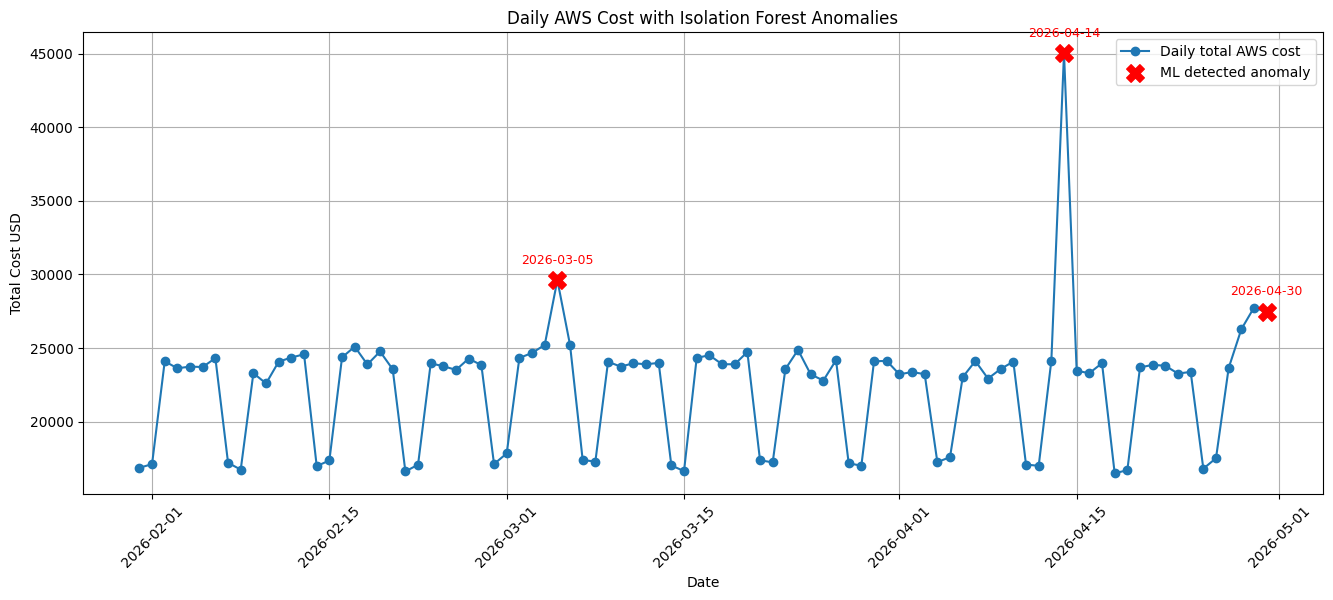

In [13]:
# ============================================================
# Visualize machine learning anomaly results
#
# Blue line:
# Daily total AWS cost
#
# Red X markers:
# Days flagged as anomalies by Isolation Forest
#
# Goal:
# Visually validate whether the ML model identifies meaningful
# cost spikes or unusual daily behaviour.
# ============================================================

plt.figure(figsize=(16, 6))

plt.plot(
    daily_ml_df["date"],
    daily_ml_df["total_cost_usd"],
    marker="o",
    label="Daily total AWS cost"
)

plt.scatter(
    ml_anomalies_df["date"],
    ml_anomalies_df["total_cost_usd"],
    color="red",
    marker="X",
    s=160,
    label="ML detected anomaly",
    zorder=10
)

for _, row in ml_anomalies_df.iterrows():
    plt.annotate(
        row["date"].strftime("%Y-%m-%d"),
        (row["date"], row["total_cost_usd"]),
        textcoords="offset points",
        xytext=(0, 12),
        ha="center",
        fontsize=9,
        color="red"
    )

plt.title("Daily AWS Cost with Isolation Forest Anomalies")
plt.xlabel("Date")
plt.ylabel("Total Cost USD")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

## Contamination sensitivity analysis

In [14]:
# ============================================================
# Run contamination sensitivity analysis
#
# Purpose:
# Evaluate how sensitive the anomaly results are to the
# contamination parameter.
#
# Why not a traditional GridSearchCV:
# This is an unsupervised problem and no labelled anomaly
# target is available. Therefore, model selection should focus
# on stability and business interpretability rather than
# optimizing a supervised scoring metric.
# ============================================================

contamination_values = [
    0.01,
    0.02,
    0.03,
    0.04,
    0.05
]

sensitivity_results = []

for contamination in contamination_values:
    
    test_model = Pipeline(
        steps=[
            (
                "scaler",
                StandardScaler()
            ),
            (
                "isolation_forest",
                IsolationForest(
                    n_estimators=300,
                    contamination=contamination,
                    random_state=42
                )
            )
        ]
    )
    
    test_model.fit(X)
    
    labels = test_model.predict(X)
    scores = test_model.decision_function(X)
    
    temp_df = daily_ml_df[["date", "total_cost_usd"]].copy()
    temp_df["contamination"] = contamination
    temp_df["label"] = labels
    temp_df["score"] = scores
    
    detected_dates = (
        temp_df[temp_df["label"] == -1]["date"]
        .dt.strftime("%Y-%m-%d")
        .tolist()
    )
    
    sensitivity_results.append(
        {
            "contamination": contamination,
            "number_of_anomalies": len(detected_dates),
            "detected_dates": detected_dates
        }
    )

sensitivity_df = pd.DataFrame(sensitivity_results)

display(sensitivity_df)

,contamination,number_of_anomalies,detected_dates
0,0.01,1,[2026-04-14]
1,0.02,2,"[2026-03-05, 2026-04-14]"
2,0.03,3,"[2026-03-05, 2026-04-14, 2026-04-30]"
3,0.04,4,"[2026-03-05, 2026-04-14, 2026-04-25, 2026-04-30]"
4,0.05,5,"[2026-03-05, 2026-04-14, 2026-04-25, 2026-04-29, 2026-04-30]"


## Select top 3 ML anomalies

In [15]:
# ============================================================
# Select top 3 anomalies
#
# Purpose:
# The task asks for three candidate cost anomalies.
# We select the three most anomalous days based on the
# Isolation Forest anomaly score.
#
# Interpretation:
# Lower anomaly score means stronger anomaly.
# ============================================================

top_3_ml_anomalies = (
    daily_ml_df
    .sort_values("ml_anomaly_score")
    .head(3)
)

display(
    top_3_ml_anomalies[
        [
            "date",
            "total_cost_usd",
            "cost_diff_abs",
            "cost_diff_pct",
            "cost_z_score_7d",
            "avg_cpu_usage_cores",
            "avg_memory_usage_mb",
            "ml_anomaly_score"
        ]
    ]
)

,date,total_cost_usd,cost_diff_abs,cost_diff_pct,cost_z_score_7d,avg_cpu_usage_cores,avg_memory_usage_mb,ml_anomaly_score
73,2026-04-14,"45,023.11","20,894.66",0.87,2.14,1.53,"2,064.70",-0.28
33,2026-03-05,"29,610.55","4,404.87",0.17,1.46,1.16,"1,881.18",-0.17
89,2026-04-30,"27,440.17",-303.44,-0.01,0.93,0.72,"1,705.08",-0.00


## Root cause analysis for top 3 anomaly dates

In [16]:
# ============================================================
# Root cause analysis for top 3 anomaly dates
#
# Purpose:
# Drill down from daily anomaly dates into the original AWS CUR
# dimensions to identify likely cost drivers.
#
# Dimensions:
# - account_id
# - service
# - usage_type
# - region
# ============================================================

for anomaly_date in top_3_ml_anomalies["date"]:
    
    print("=" * 100)
    print("Anomaly date:", anomaly_date.date())
    
    root_cause_df = (
        aws_cur_df[aws_cur_df["date"] == anomaly_date]
        .groupby(
            [
                "account_id",
                "service",
                "usage_type",
                "region"
            ],
            as_index=False
        )
        .agg(
            total_cost_usd=("cost_usd", "sum"),
            total_usage_quantity=("usage_quantity", "sum")
        )
        .sort_values("total_cost_usd", ascending=False)
    )
    
    root_cause_df["cost_share_pct"] = (
        root_cause_df["total_cost_usd"] /
        root_cause_df["total_cost_usd"].sum()
    ) * 100
    
    display(root_cause_df.head(10))

Anomaly date: 2026-04-14


,account_id,service,usage_type,region,total_cost_usd,total_usage_quantity,cost_share_pct
5,acct_001,AmazonEC2,BoxUsage:m5.xlarge,us-east-1,"12,612.81","65,691.57",28.01
4,acct_001,AmazonEC2,BoxUsage:m5.xlarge,eu-west-1,"11,950.07","62,239.98",26.54
14,acct_002,AmazonEC2,BoxUsage:m5.xlarge,us-west-2,"1,698.60","8,846.89",3.77
47,acct_005,AmazonEC2,BoxUsage:m5.xlarge,us-west-2,"1,176.60","6,128.14",2.61
46,acct_005,AmazonEC2,BoxUsage:m5.xlarge,us-east-1,970.90,"5,056.79",2.16
16,acct_002,AmazonRDS,InstanceUsage:db.r5.large,us-west-2,701.48,"2,922.84",1.56
8,acct_001,AmazonRDS,InstanceUsage:db.r5.large,eu-west-1,646.79,"2,694.97",1.44
9,acct_001,AmazonRDS,InstanceUsage:db.r5.large,us-east-1,631.27,"2,630.29",1.40
65,acct_007,AmazonEC2,BoxUsage:m5.xlarge,eu-west-1,594.85,"3,098.19",1.32
64,acct_007,AmazonEC2,BoxUsage:m5.xlarge,eu-central-1,532.71,"2,774.53",1.18


Anomaly date: 2026-03-05


,account_id,service,usage_type,region,total_cost_usd,total_usage_quantity,cost_share_pct
4,acct_001,AmazonEC2,BoxUsage:m5.xlarge,eu-west-1,"4,606.46","23,325.36",15.56
5,acct_001,AmazonEC2,BoxUsage:m5.xlarge,us-east-1,"3,421.82","17,557.58",11.56
14,acct_002,AmazonEC2,BoxUsage:m5.xlarge,us-west-2,"1,951.96","10,290.61",6.59
47,acct_005,AmazonEC2,BoxUsage:m5.xlarge,us-west-2,"1,068.93","5,531.51",3.61
46,acct_005,AmazonEC2,BoxUsage:m5.xlarge,us-east-1,937.65,"4,907.94",3.17
16,acct_002,AmazonRDS,InstanceUsage:db.r5.large,us-west-2,759.76,"3,213.98",2.57
78,acct_008,AmazonEC2,BoxUsage:m5.xlarge,eu-west-1,736.67,"3,810.50",2.49
9,acct_001,AmazonRDS,InstanceUsage:db.r5.large,us-east-1,718.14,"3,088.25",2.43
64,acct_007,AmazonEC2,BoxUsage:m5.xlarge,eu-central-1,670.83,"3,511.36",2.27
80,acct_008,AmazonEC2,BoxUsage:m5.xlarge,us-west-2,632.05,"3,315.32",2.13


Anomaly date: 2026-04-30


,account_id,service,usage_type,region,total_cost_usd,total_usage_quantity,cost_share_pct
14,acct_002,AmazonEC2,BoxUsage:m5.xlarge,us-west-2,"1,777.20","9,256.25",6.48
5,acct_001,AmazonEC2,BoxUsage:m5.xlarge,us-east-1,"1,686.28","8,782.70",6.15
47,acct_005,AmazonEC2,BoxUsage:m5.xlarge,us-west-2,"1,372.98","7,150.96",5.00
4,acct_001,AmazonEC2,BoxUsage:m5.xlarge,eu-west-1,"1,350.48","7,033.75",4.92
46,acct_005,AmazonEC2,BoxUsage:m5.xlarge,us-east-1,"1,296.77","6,754.01",4.73
16,acct_002,AmazonRDS,InstanceUsage:db.r5.large,us-west-2,866.09,"3,608.70",3.16
64,acct_007,AmazonEC2,BoxUsage:m5.xlarge,eu-central-1,784.33,"4,085.05",2.86
8,acct_001,AmazonRDS,InstanceUsage:db.r5.large,eu-west-1,779.61,"3,248.37",2.84
9,acct_001,AmazonRDS,InstanceUsage:db.r5.large,us-east-1,776.99,"3,237.44",2.83
80,acct_008,AmazonEC2,BoxUsage:m5.xlarge,us-west-2,708.90,"3,692.18",2.58


## Kubernetes context for top 3 anomaly dates

In [17]:
# ============================================================
# Kubernetes context for top 3 anomaly dates
#
# Purpose:
# Check whether detected cost anomalies are aligned with
# Kubernetes CPU or memory spikes.
#
# This helps distinguish:
# - workload-driven cost increases
# - billing/pricing/configuration anomalies
# ============================================================

for anomaly_date in top_3_ml_anomalies["date"]:
    
    print("=" * 100)
    print("Kubernetes context for anomaly date:", anomaly_date.date())
    
    k8s_context_df = (
        k8s_metrics_df[k8s_metrics_df["date"] == anomaly_date]
        .groupby("pod_name", as_index=False)
        .agg(
            avg_cpu_usage_cores=("cpu_usage_cores", "mean"),
            max_cpu_usage_cores=("cpu_usage_cores", "max"),
            avg_memory_usage_mb=("memory_usage_mb", "mean"),
            max_memory_usage_mb=("memory_usage_mb", "max"),
            avg_cpu_utilization_ratio=("cpu_utilization_ratio", "mean"),
            max_cpu_utilization_ratio=("cpu_utilization_ratio", "max"),
            avg_memory_utilization_ratio=("memory_utilization_ratio", "mean"),
            max_memory_utilization_ratio=("memory_utilization_ratio", "max")
        )
        .sort_values("max_cpu_usage_cores", ascending=False)
    )
    
    display(k8s_context_df.head(10))

Kubernetes context for anomaly date: 2026-04-14


,pod_name,avg_cpu_usage_cores,max_cpu_usage_cores,avg_memory_usage_mb,max_memory_usage_mb,avg_cpu_utilization_ratio,max_cpu_utilization_ratio,avg_memory_utilization_ratio,max_memory_utilization_ratio
5,model-serving-9b3e7,8.10,12.76,"9,000.13","13,530.60",2.02,3.19,1.10,1.65
3,data-pipeline-4a2c1,1.17,1.99,"2,641.63","3,946.50",0.59,0.99,0.64,0.96
1,batch-processor-1d5f3,0.58,0.89,"1,384.81","2,057.60",0.58,0.89,0.68,1.00
2,cache-layer-5f1d9,0.33,0.58,756.19,"1,107.00",0.66,1.16,0.74,1.08
0,api-gateway-7f8d9,0.31,0.44,374.80,588.80,0.61,0.87,0.73,1.15
6,monitoring-agent-6c8a2,0.15,0.22,179.07,269.30,0.59,0.88,0.70,1.05
4,legacy-etl-2e7b4,0.08,0.14,116.28,167.90,0.04,0.07,0.03,0.04


Kubernetes context for anomaly date: 2026-03-05


,pod_name,avg_cpu_usage_cores,max_cpu_usage_cores,avg_memory_usage_mb,max_memory_usage_mb,avg_cpu_utilization_ratio,max_cpu_utilization_ratio,avg_memory_utilization_ratio,max_memory_utilization_ratio
5,model-serving-9b3e7,5.56,9.24,"7,735.65","11,794.20",1.39,2.31,0.94,1.44
3,data-pipeline-4a2c1,1.20,1.86,"2,678.50","4,109.70",0.60,0.93,0.65,1.00
1,batch-processor-1d5f3,0.59,0.91,"1,392.70","1,967.10",0.59,0.91,0.68,0.96
2,cache-layer-5f1d9,0.35,0.54,732.90,"1,038.10",0.69,1.08,0.72,1.01
0,api-gateway-7f8d9,0.24,0.37,338.96,482.00,0.47,0.74,0.66,0.94
6,monitoring-agent-6c8a2,0.15,0.21,174.42,254.10,0.58,0.84,0.68,0.99
4,legacy-etl-2e7b4,0.08,0.12,115.12,164.20,0.04,0.06,0.03,0.04


Kubernetes context for anomaly date: 2026-04-30


,pod_name,avg_cpu_usage_cores,max_cpu_usage_cores,avg_memory_usage_mb,max_memory_usage_mb,avg_cpu_utilization_ratio,max_cpu_utilization_ratio,avg_memory_utilization_ratio,max_memory_utilization_ratio
5,model-serving-9b3e7,2.50,3.97,"5,130.93","7,430.70",0.62,0.99,0.63,0.91
3,data-pipeline-4a2c1,1.13,1.82,"4,011.09","5,793.50",0.57,0.91,0.98,1.41
1,batch-processor-1d5f3,0.58,0.92,"1,346.46","1,977.60",0.58,0.92,0.66,0.97
2,cache-layer-5f1d9,0.33,0.63,773.72,"1,118.10",0.66,1.25,0.76,1.09
0,api-gateway-7f8d9,0.29,0.45,377.31,543.10,0.58,0.91,0.74,1.06
6,monitoring-agent-6c8a2,0.14,0.21,179.17,276.80,0.57,0.84,0.70,1.08
4,legacy-etl-2e7b4,0.08,0.12,116.89,164.20,0.04,0.06,0.03,0.04


## Summary table

In [18]:
# ============================================================
# Create final summary table
#
# Purpose:
# Prepare a compact, presentation-friendly table with the
# selected candidate anomalies and key supporting metrics.
# ============================================================

final_summary_df = top_3_ml_anomalies[
    [
        "date",
        "total_cost_usd",
        "cost_diff_abs",
        "cost_diff_pct",
        "cost_z_score_7d",
        "avg_cpu_usage_cores",
        "avg_memory_usage_mb",
        "ml_anomaly_score"
    ]
].copy()

final_summary_df["date"] = final_summary_df["date"].dt.strftime("%Y-%m-%d")

display(
    final_summary_df.style
    .hide(axis="index")
    .set_caption("Top 3 Candidate Cost Anomalies Detected by Isolation Forest")
    .set_properties(
        **{
            "text-align": "left",
            "white-space": "normal"
        }
    )
)

date,total_cost_usd,cost_diff_abs,cost_diff_pct,cost_z_score_7d,avg_cpu_usage_cores,avg_memory_usage_mb,ml_anomaly_score
2026-04-14,45023.105000,20894.660000,0.865976,2.137672,1.531192,2064.702976,-0.276598
2026-03-05,29610.550000,4404.870000,0.174757,1.460127,1.164820,1881.177381,-0.168600
2026-04-30,27440.170000,-303.440000,-0.010937,0.929696,0.721495,1705.080357,-0.000114


## Save output files

In [19]:
# ============================================================
# Create one final CSV output for the case study
#
# Purpose:
# Export only the top 3 Isolation Forest anomalies with:
# - ML anomaly score
# - cost metrics
# - Kubernetes context
# - main AWS root-cause contributor
# ============================================================

final_rows = []

for anomaly_rank, anomaly_date in enumerate(top_3_ml_anomalies["date"], start=1):

    # Get daily ML-level anomaly information
    anomaly_info = (
        daily_ml_df[daily_ml_df["date"] == anomaly_date]
        .iloc[0]
    )

    # Find the largest AWS cost contributor on that anomaly day
    root_cause_df = (
        aws_cur_df[aws_cur_df["date"] == anomaly_date]
        .groupby(
            ["account_id", "service", "usage_type", "region"],
            as_index=False
        )
        .agg(
            root_cause_cost_usd=("cost_usd", "sum"),
            root_cause_usage_quantity=("usage_quantity", "sum")
        )
        .sort_values("root_cause_cost_usd", ascending=False)
    )

    main_root_cause = root_cause_df.iloc[0]

    final_rows.append({
        "anomaly_rank": anomaly_rank,
        "date": anomaly_date.strftime("%Y-%m-%d"),
        "ml_anomaly_score": anomaly_info["ml_anomaly_score"],
        "total_cost_usd": anomaly_info["total_cost_usd"],
        "cost_diff_abs": anomaly_info["cost_diff_abs"],
        "cost_diff_pct": anomaly_info["cost_diff_pct"],
        "cost_z_score_7d": anomaly_info["cost_z_score_7d"],
        "avg_cpu_usage_cores": anomaly_info["avg_cpu_usage_cores"],
        "max_cpu_usage_cores": anomaly_info["max_cpu_usage_cores"],
        "avg_memory_usage_mb": anomaly_info["avg_memory_usage_mb"],
        "max_memory_usage_mb": anomaly_info["max_memory_usage_mb"],
        "root_cause_account_id": main_root_cause["account_id"],
        "root_cause_service": main_root_cause["service"],
        "root_cause_usage_type": main_root_cause["usage_type"],
        "root_cause_region": main_root_cause["region"],
        "root_cause_cost_usd": main_root_cause["root_cause_cost_usd"],
        "root_cause_usage_quantity": main_root_cause["root_cause_usage_quantity"]
    })

final_anomaly_report_df = pd.DataFrame(final_rows)

display(final_anomaly_report_df)

final_anomaly_report_df.to_csv(
    "../synnepha_exercise_90d/results/isolation_forest_results/final_top_3_isolation_forest_anomaly_report.csv",
    index=False
)

print("Final CSV file saved: final_top_3_isolation_forest_anomaly_report.csv")

,anomaly_rank,date,ml_anomaly_score,total_cost_usd,cost_diff_abs,cost_diff_pct,cost_z_score_7d,avg_cpu_usage_cores,max_cpu_usage_cores,avg_memory_usage_mb,max_memory_usage_mb,root_cause_account_id,root_cause_service,root_cause_usage_type,root_cause_region,root_cause_cost_usd,root_cause_usage_quantity
0,1,2026-04-14,-0.28,"45,023.11","20,894.66",0.87,2.14,1.53,12.76,"2,064.70","13,530.60",acct_001,AmazonEC2,BoxUsage:m5.xlarge,us-east-1,"12,612.81","65,691.57"
1,2,2026-03-05,-0.17,"29,610.55","4,404.87",0.17,1.46,1.16,9.24,"1,881.18","11,794.20",acct_001,AmazonEC2,BoxUsage:m5.xlarge,eu-west-1,"4,606.46","23,325.36"
2,3,2026-04-30,-0.00,"27,440.17",-303.44,-0.01,0.93,0.72,3.97,"1,705.08","7,430.70",acct_002,AmazonEC2,BoxUsage:m5.xlarge,us-west-2,"1,777.20","9,256.25"


Final CSV file saved: final_top_3_isolation_forest_anomaly_report.csv
